In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
import re 

import altair as alt

alt.__version__

# plots

import matplotlib.pyplot as plt
import numpy as np


# Basic setup

In [7]:
# Notebook is inside I2R/notebooks
PROJECT = Path("..").resolve()

DATA_RAW = PROJECT / "data" / "raw"
DATA_PROCESSED = PROJECT / "data" / "processed"
OUTPUTS = PROJECT / "outputs"

print("Project root:", PROJECT)
print("Raw data path:", DATA_RAW)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

print("Paths ready:", DATA_RAW)


Project root: C:\Users\Michelle\I2R
Raw data path: C:\Users\Michelle\I2R\data\raw
Paths ready: C:\Users\Michelle\I2R\data\raw


# Create image annotation table

Manually collect 100 Google images and annoate them

-- Trial with 10 samples --


In [8]:
# list 10 images
from pathlib import Path

PROJECT = Path("..").resolve()
IMG_DIR = PROJECT / "images" / "examples" / "pilot10"

def extract_number(filename):
    return int(re.search(r'\d+', filename).group())

image_files = sorted(
    [p.name for p in IMG_DIR.glob("*.png")],
    key=extract_number
)

image_files

['trial_img1.png',
 'trial_img2.png',
 'trial_img3.png',
 'trial_img4.png',
 'trial_img5.png',
 'trial_img6.png',
 'trial_img7.png',
 'trial_img8.png',
 'trial_img9.png',
 'trial_img10.png']

In [9]:
# Load csv 

DATA_RAW = PROJECT / "data" / "raw"

csv_path = DATA_RAW / "Charts trial - toFill_trial_10samples.csv"

df = pd.read_csv(csv_path)

# drop rows that contain the image

df_clean = df.iloc[0::2].copy()
df_clean

,Charts,Vertical (yes),Title (yes),"Title (centered: 1, left: 2, right: 3)",Title black,"Title size 0=average, 1=small, 2=large",Title size large,Subtitle (yes),"Outline chart (no = 0, yes = 1, partly = 2)","Legend: (no legend = 0, left = 1, right = 2, top = 3, bottom = 4, top-left = 5, top-right = 6)",legend title,Legend title color (yes),Legend outline (yes),Gridlines (yes),"Gridlines (0=none, 1=H, 2=V, 3=H&V)",H gridlines,"X Labels: diagonal: 0, horizontal:1, vertical: 2)",X labels diagonal,X labels vertical,"Y labels, 0:diagonal, horizontal:1, vertical:2)",Y labels diagonal,Y labels vertical,Labels colored (yes),"Direct labeling (0: no, 1: no quantitative axis labels, 2: labels but still axis labels)","Direct labeling (base: 0, outside: 1, center: 2)","Aspect ratio (square: 0, more horizontal: 1, more vertical: 2)","Samples (1-10: 0, 11-20:1, 21-30: 2, ...)",Colored bars (yes),Rounded corners,Outline bars,Background no white,"Ticks (0: no, 1: X, 2, X & Y, 3: Y)"
0,trial_img1,1.0,0.0,0.0,NaN,NaN,0.0,NaN,2.0,0.0,NaN,NaN,NaN,1.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,trial_img2,1.0,1.0,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,trial_img3,1.0,1.0,1.0,1.0,0.0,0.0,NaN,2.0,0.0,0.0,NaN,NaN,0.0,1.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0
6,trial_img4,1.0,1.0,1.0,1.0,0.0,0.0,NaN,1.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,1.0,0.0,1.0,0.0,0.0
8,trial_img5,1.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,4.0,0.0,1.0,0.0,1.0,1.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0
10,trial_img6,0.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,NaN,NaN,1.0,2.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0
12,trial_img7,1.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,6.0,0.0,1.0,0.0,1.0,3.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,1.0,0.0,1.0,0.0,0.0
14,trial_img8,0.0,0.0,NaN,NaN,NaN,NaN,NaN,2.0,6.0,0.0,1.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0
16,trial_img9,1.0,1.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0
18,trial_img10,1.0,0.0,NaN,NaN,NaN,0.0,NaN,2.0,2.0,0.0,1.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,2.0,1.0,0.0,0.0,0.0,0.0


In [10]:
# For each row, calculate probabilities of values it contains 

probabilities = {}

for col in df_clean.columns:
    probs = df_clean[col].value_counts(normalize=True, dropna=False) # set dropna to false because in some cases NaN has meaning
    probabilities[col] = probs

probabilities


{'Charts': Charts
 trial_img1     0.1
 trial_img2     0.1
 trial_img3     0.1
 trial_img4     0.1
 trial_img5     0.1
 trial_img6     0.1
 trial_img7     0.1
 trial_img8     0.1
 trial_img9     0.1
 trial_img10    0.1
 Name: proportion, dtype: float64,
 'Vertical (yes)': Vertical (yes)
 1.0    0.8
 0.0    0.2
 Name: proportion, dtype: float64,
 'Title (yes)': Title (yes)
 1.0    0.7
 0.0    0.3
 Name: proportion, dtype: float64,
 'Title (centered: 1, left: 2, right: 3)': Title (centered: 1, left: 2, right: 3)
 1.0    0.5
 NaN    0.3
 0.0    0.1
 2.0    0.1
 Name: proportion, dtype: float64,
 'Title black': Title black
 1.0    0.5
 NaN    0.4
 0.0    0.1
 Name: proportion, dtype: float64,
 'Title size 0=average, 1=small, 2=large': Title size 0=average, 1=small, 2=large
 NaN    0.4
 0.0    0.4
 1.0    0.2
 Name: proportion, dtype: float64,
 'Title size large': Title size large
 0.0    0.6
 NaN    0.2
 1.0    0.2
 Name: proportion, dtype: float64,
 'Subtitle (yes)': Subtitle (yes)
 NaN   

# Create mapping from columns to Altair parameters

### Title 
- Title:  
-'Title (yes)'  
1=Yes, 0=No  
-'Title (centered: 1, left: 2, right: 3)'  
NaN=no title, 1=centered, 2=left, 3=right  
-'Title black'  
NaN=no title, 1=yes, 0=different color  
-'Title size 0=average, 1=small, 2=large'  
NaN=no title, 0=average, 1=small, 2=large    
- Subtile:  
-'Subtitle (yes)'  
1=yes, 0=no   


### Chart Level  
- Width:  
- Aspect ratio:  
-'Aspect ratio (square: 0, more horizontal: 1, more vertical: 2)'    
0=square, 1=horizontal, 2=vertical  
- Background:  
-'Background no white'    
0=white background 1=other color  
- Outline:   
-'Outline chart (no = 0, yes = 1, partly = 2)'   
0=no outline, 1=yes, 2=partly(x and y axes only)  

### Axis  
- Grid:  
-'Gridlines (yes)'  
0=no, 1=yes  
-'Gridlines (0=none, 1=H, 2=V, 3=H&V)'  
0=no gridlines, 1=horizontal, 2=vertical, 3=both h&v       
- X axis:  
-'X Labels: diagonal: 0, horizontal:1, vertical: 2)'  
0=diagonal labels, 1=horizontal, 2=vertical  
- Y axis:  
-'Y labels, 0:diagonal, horizontal:1, vertical:2)'  
0=diagonal labels, 1=horizontal, 2=vertical  
- Labels:  
-'Labels colored (yes)'  
0= no colored labels, 1=colored labels  
-'Direct labeling (0: no, 1: no quantitative axis labels, 2: labels but still axis labels)'  
0=no direct labels, 1= no quantitative axis labels, 2=labels but still axis labels  
-'Direct labeling (base: 0, outside: 1, center: 2)'  
NaN=no direct labels, 0= labels at base, 1=labels outside, 2= labels in center   
- Ticks:  
-'Ticks (0: no, 1: X, 2, X & Y, 3: Y)'  
0=no ticks, 1=x only, 2=X&Y, 3=Y only  
- Domain  
- LabelFontSize  

### Legend  
- Legend:
-'Legend: (no legend = 0, left = 1, right = 2, top = 3, bottom = 4, top-left = 5, top-right = 6)'   
0=no legend, 1=left, 2=right, 3=top, 4=bottom, 5=top-left, 6=top right  
- Orient  
- Title: 'legend title', 'Legend title color (yes)'  
- LabelFontSize  
- Outline: 'Legend outline (yes)'    

### Mark (bar)
- Samples: 'Samples (1-10: 0, 11-20:1, 21-30: 2, ...)'   
- Color: 'Colored bars (yes)'    
- Opacity  
- Stroke  
- Bars: 'Vertical (yes)', 'Rounded corners', 'Outline bars' 

In [11]:

help(alt.Axis)

Help on class Axis in module altair.vegalite.v6.schema.core:

class Axis(VegaLiteSchema)
 |  Axis(aria: 'Optional[bool | Parameter | SchemaBase | Map]' = Undefined, bandPosition: 'Optional[float | Parameter | SchemaBase | Map]' = Undefined, description: 'Optional[str | Parameter | SchemaBase | Map]' = Undefined, domain: 'Optional[bool]' = Undefined, domainCap: 'Optional[Parameter | SchemaBase | Map | StrokeCap_T]' = Undefined, domainColor: 'Optional[str | Parameter | SchemaBase | Map | ColorName_T | None]' = Undefined, domainDash: 'Optional[Parameter | SchemaBase | Sequence[float] | Map]' = Undefined, domainDashOffset: 'Optional[float | Parameter | SchemaBase | Map]' = Undefined, domainOpacity: 'Optional[float | Parameter | SchemaBase | Map]' = Undefined, domainWidth: 'Optional[float | Parameter | SchemaBase | Map]' = Undefined, format: 'Optional[str | SchemaBase | Map]' = Undefined, formatType: 'Optional[str]' = Undefined, grid: 'Optional[bool]' = Undefined, gridCap: 'Optional[Paramet

Train dataset


In [13]:
# Load csv train

DATA_TRAIN = PROJECT / "data" / "train"

csv_train = DATA_TRAIN / "Warehouse_and_Retail_Sales.csv"

df_train = pd.read_csv(csv_train)

df_train

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.00
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.00
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.00
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.00
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.00
...,...,...,...,...,...,...,...,...,...
307640,2020,9,LEGENDS LTD,99753,DUTCHESS DE BOURGOGNE NR - 750ML,BEER,0.00,0.0,5.00
307641,2020,9,ANHEUSER BUSCH INC,9997,HOEGAARDEN 4/6NR - 12OZ,BEER,66.12,37.0,240.75
307642,2020,9,COASTAL BREWING COMPANY LLC,99970,DOMINION OAK BARREL STOUT 4/6 NR - 12OZ,BEER,2.25,0.0,0.00
307643,2020,9,BOSTON BEER CORPORATION,99990,SAM ADAMS SUMMER VARIETY 12PK NR,BEER,20.50,0.0,0.00


In [14]:
# Basic shape

print("Shape:", df_train.shape)
print("\nColumns:\n", df_train.columns.tolist())
print("\nDtypes:\n", df_train.dtypes)


Shape: (307645, 9)

Columns:
 ['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION', 'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']

Dtypes:
 YEAR                  int64
MONTH                 int64
SUPPLIER                str
ITEM CODE               str
ITEM DESCRIPTION        str
ITEM TYPE               str
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object


In [15]:
# Missing values

missing = df_train.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(2)

missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_table[missing_table["missing_count"] > 0])

,missing_count,missing_pct
SUPPLIER,167,0.05
RETAIL SALES,3,0.00
ITEM TYPE,1,0.00


In [17]:
possible_na_strings = ["", "NA", "N/A", "null", "None", "UNKNOWN", "unknown"]

text_cols = df_train.select_dtypes(include=["object"]).columns
for c in text_cols:
    vals = df_train[c].astype(str).str.strip().value_counts(dropna=False).head(10)
    print(f"\nTop values for {c}:")
    print(vals)


Top values for SUPPLIER:
SUPPLIER
REPUBLIC NATIONAL DISTRIBUTING CO       20995
LEGENDS LTD                             13634
SOUTHERN GLAZERS WINE AND SPIRITS       11720
E & J GALLO WINERY                      10816
THE COUNTRY VINTNER, LLC DBA WINEBOW    10669
MONSIEUR TOUTON SELECTION               10360
A VINTNERS SELECTIONS                    9994
BACCHUS IMPORTERS LTD                    9150
DIAGEO NORTH AMERICA INC                 7520
RELIABLE CHURCHILL LLLP                  6971
Name: count, dtype: int64

Top values for ITEM CODE:
ITEM CODE
100293    24
100749    24
10103     24
101532    24
10197     24
101974    24
102032    24
102148    24
10243     24
10245     24
Name: count, dtype: int64

Top values for ITEM DESCRIPTION:
ITEM DESCRIPTION
BURGANS ALBARINO - 750ML                     44
SANTA JULIA TORRONTES SUSTAINABLE - 750ML    39
LA VIELLE FERME CDV RED - 750ML              35
LINGANORE BLACK RAVEN - 750ML                34
MCCLINTOCK HERITAGE WHITE WHISKEY - 750ML  

C:\Users\Michelle\AppData\Local\Temp\ipykernel_22136\1970740960.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_train.select_dtypes(include=["object"]).columns


In [18]:
# datetime column for year + month
# for line charts


# Ensure YEAR and MONTH are numeric
df_train["YEAR"] = pd.to_numeric(df_train["YEAR"], errors="coerce")
df_train["MONTH"] = pd.to_numeric(df_train["MONTH"], errors="coerce")

# Check invalid months
invalid_months = df_train.loc[~df_train["MONTH"].between(1, 12), "MONTH"]
print("Invalid months count:", invalid_months.shape[0])

# Create date column (first day of month)
df_train["date"] = pd.to_datetime(
    dict(year=df_train["YEAR"].astype("Int64"), month=df_train["MONTH"].astype("Int64"), day=1),
    errors="coerce"
)

print("date min:", df_train["date"].min())
print("date max:", df_train["date"].max())
print("date missing:", df_train["date"].isna().sum())

Invalid months count: 0
date min: 2017-06-01 00:00:00
date max: 2020-09-01 00:00:00
date missing: 0


In [19]:
# column cardinalities (category sizes)
# which columns are usable for bar/pie

cat_candidates = ["SUPPLIER", "ITEM TYPE", "ITEM DESCRIPTION", "ITEM CODE"]
for c in cat_candidates:
    if c in df_train.columns:
        print(f"{c}: nunique = {df_train[c].nunique(dropna=True)}")

SUPPLIER: nunique = 396
ITEM TYPE: nunique = 8
ITEM DESCRIPTION: nunique = 34822
ITEM CODE: nunique = 34056


In [20]:
# numeric columns sanity 

num_cols = ["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"]
for c in num_cols:
    df_train[c] = pd.to_numeric(df_train[c], errors="coerce")

summary = df_train[num_cols].describe().T
summary["pct_zero"] = (df_train[num_cols].eq(0).mean() * 100).round(2)
summary["pct_negative"] = (df_train[num_cols].lt(0).mean() * 100).round(4)
display(summary)

,count,mean,std,min,25%,50%,75%,max,pct_zero,pct_negative
RETAIL SALES,307642.0,7.024071,30.986238,-6.49,0.0,0.32,3.2675,2739.00,39.56,0.0367
RETAIL TRANSFERS,307645.0,6.936465,30.237195,-38.49,0.0,0.00,3.0000,1990.83,61.26,0.3303
WAREHOUSE SALES,307645.0,25.294597,249.916798,-7800.00,0.0,1.00,5.0000,18317.00,31.51,0.2327


In [21]:
# num rows per month, for sampling windows 

rows_per_month = df_train.groupby("date").size().sort_index()
print(rows_per_month.head())
print(rows_per_month.tail())

print("\nRows per month - summary:")
print(rows_per_month.describe())

date
2017-06-01    13628
2017-07-01    13022
2017-08-01    13590
2017-09-01    13386
2017-10-01    13626
dtype: int64
date
2019-11-01    12849
2020-01-01    11987
2020-03-01    11523
2020-07-01    11190
2020-09-01    11578
dtype: int64

Rows per month - summary:
count       24.000000
mean     12818.541667
std        839.031014
min      11190.000000
25%      12376.500000
50%      12791.500000
75%      13355.250000
max      14532.000000
dtype: float64


In [22]:
# aggregation pattern for each chart type

# line, total retail sales over time

line_total = df_train.groupby("date")["RETAIL SALES"].sum().sort_index()
display(line_total.head())
display(line_total.tail())

print("Unique months:", line_total.shape[0])

date
2017-06-01    97357.26
2017-07-01    92625.29
2017-08-01    87111.78
2017-09-01    90452.60
2017-10-01    89236.96
Name: RETAIL SALES, dtype: float64

date
2019-11-01    101631.31
2020-01-01     74318.77
2020-03-01    109411.29
2020-07-01     94538.96
2020-09-01     82108.68
Name: RETAIL SALES, dtype: float64

Unique months: 24


In [23]:
# bar chart, total retail sales by item type

bar_type = (
    df_train.groupby("ITEM TYPE")["RETAIL SALES"].sum()
    .sort_values(ascending=False)
)
display(bar_type.head(15))

ITEM TYPE
LIQUOR          802691.43
WINE            746498.59
BEER            574220.53
NON-ALCOHOL      34084.31
STR_SUPPLIES      2740.88
REF                663.63
KEGS                 0.00
DUNNAGE              0.00
Name: RETAIL SALES, dtype: float64

In [24]:
# pie chart, share by item type for a random month


rng = np.random.default_rng(42)
random_month = rng.choice(df_train["date"].dropna().unique())

pie_month = (
    df_train[df_train["date"] == random_month]
    .groupby("ITEM TYPE")["RETAIL SALES"].sum()
    .sort_values(ascending=False)
)

print("Random month:", random_month)
display(pie_month)

Random month: 2020-07-01T00:00:00.000000


ITEM TYPE
LIQUOR          35430.95
BEER            28907.53
WINE            25583.51
NON-ALCOHOL      4527.57
STR_SUPPLIES       81.23
REF                 8.17
KEGS                0.00
DUNNAGE             0.00
Name: RETAIL SALES, dtype: float64

In [25]:
# scatter: retail vs warehouse (raw vs aggregated)

#raw

scatter_raw = df_train[["RETAIL SALES", "WAREHOUSE SALES"]].dropna()
print("Raw scatter points:", len(scatter_raw))
print(scatter_raw.describe())

Raw scatter points: 307642
        RETAIL SALES  WAREHOUSE SALES
count  307642.000000    307642.000000
mean        7.024071        25.294844
std        30.986238       249.918004
min        -6.490000     -7800.000000
25%         0.000000         0.000000
50%         0.320000         1.000000
75%         3.267500         5.000000
max      2739.000000     18317.000000


In [26]:
# aggregated by supplier

scatter_supplier = (
    df_train.groupby("SUPPLIER")[["RETAIL SALES", "WAREHOUSE SALES"]].sum()
    .reset_index()
)

print("Supplier scatter points:", len(scatter_supplier))
display(scatter_supplier.sort_values("RETAIL SALES", ascending=False).head(10))

Supplier scatter points: 396


,SUPPLIER,RETAIL SALES,WAREHOUSE SALES
108,E & J GALLO WINERY,166170.53,197463.78
90,DIAGEO NORTH AMERICA INC,145343.20,170564.63
76,CONSTELLATION BRANDS,131664.79,119399.51
15,ANHEUSER BUSCH INC,109960.82,1331170.84
173,JIM BEAM BRANDS CO,96164.04,7942.81
214,MILLER BREWING COMPANY,87156.44,1425428.71
81,CROWN IMPORTS,84437.66,1651871.51
293,SAZERAC CO,70414.62,16916.29
26,BACARDI USA INC,66610.23,9999.07
344,THE WINE GROUP,64270.04,72191.57


In [27]:
# dataset capabilities 

capabilities = {
    "temporal": {"year": "YEAR", "month": "MONTH", "date": "date"},
    "categorical": ["ITEM TYPE", "SUPPLIER"],  # keep high-value ones
    "categorical_high_cardinality": ["ITEM DESCRIPTION", "ITEM CODE"],
    "numeric": ["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"],
    "recommended": {
        "pie": {"category": "ITEM TYPE", "value": "RETAIL SALES", "k_range": [3, 8]},
        "bar": {"category": "ITEM TYPE", "value": "RETAIL SALES", "k_range": [5, 20]},
        "line": {"x": "date", "y": "RETAIL SALES", "group_optional": "ITEM TYPE"},
        "scatter": {"x": "RETAIL SALES", "y": "WAREHOUSE SALES", "group_optional": "SUPPLIER"},
    },
}

capabilities

{'temporal': {'year': 'YEAR', 'month': 'MONTH', 'date': 'date'},
 'categorical': ['ITEM TYPE', 'SUPPLIER'],
 'categorical_high_cardinality': ['ITEM DESCRIPTION', 'ITEM CODE'],
 'numeric': ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
 'recommended': {'pie': {'category': 'ITEM TYPE',
   'value': 'RETAIL SALES',
   'k_range': [3, 8]},
  'bar': {'category': 'ITEM TYPE',
   'value': 'RETAIL SALES',
   'k_range': [5, 20]},
  'line': {'x': 'date', 'y': 'RETAIL SALES', 'group_optional': 'ITEM TYPE'},
  'scatter': {'x': 'RETAIL SALES',
   'y': 'WAREHOUSE SALES',
   'group_optional': 'SUPPLIER'}}}

Generate plots


In [29]:
# Ensure numeric
num_cols = ["RETAIL SALES", "RETAIL TRANSFERS", "WAREHOUSE SALES"]
for c in num_cols:
    df_train[c] = pd.to_numeric(df_train[c], errors="coerce")

# Ensure date exists
df_train["date"] = pd.to_datetime(
    dict(year=df_train["YEAR"], month=df_train["MONTH"], day=1),
    errors="coerce"
)

df_train = df_train.dropna(subset=["date"])


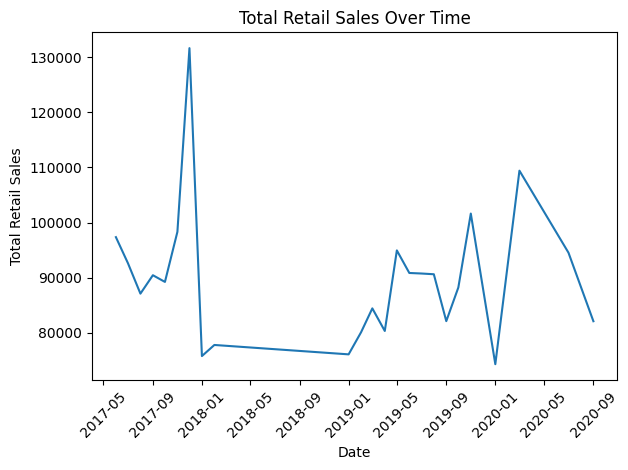

In [30]:
# line

line_data = (
    df_train.groupby("date")["RETAIL SALES"]
    .sum()
    .sort_index()
)

plt.figure()
plt.plot(line_data.index, line_data.values)
plt.xlabel("Date")
plt.ylabel("Total Retail Sales")
plt.title("Total Retail Sales Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

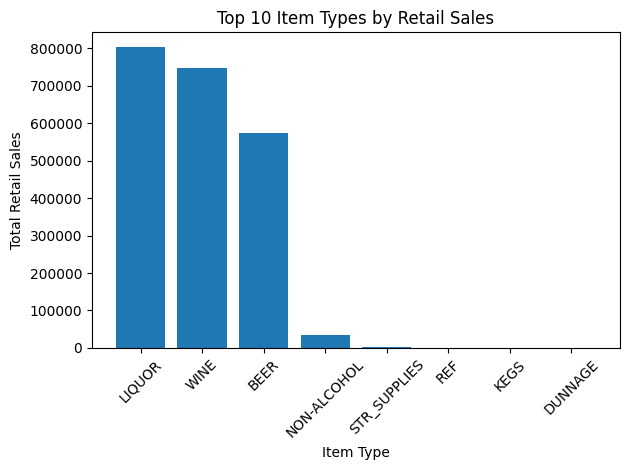

In [31]:
# bar

bar_data = (
    df_train.groupby("ITEM TYPE")["RETAIL SALES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.bar(bar_data.index, bar_data.values)
plt.xlabel("Item Type")
plt.ylabel("Total Retail Sales")
plt.title("Top 10 Item Types by Retail Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

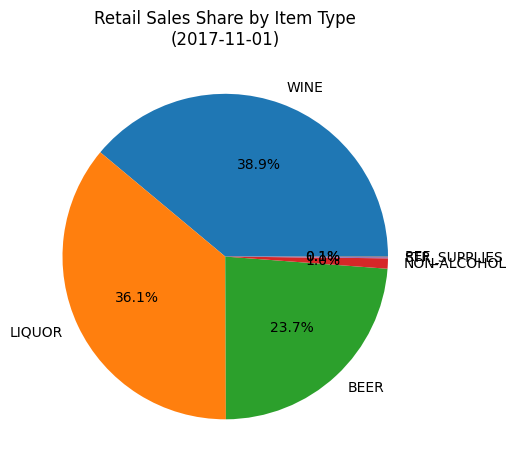

In [36]:
# pie

# Pick random month
random_month = pd.to_datetime(
    np.random.choice(df_train["date"].unique())
)

pie_data = (
    df_train[df_train["date"] == random_month]
    .groupby("ITEM TYPE")["RETAIL SALES"]
    .sum()
    .sort_values(ascending=False)
)

# Keep top 6, rest into "Other"
top_k = 6
pie_top = pie_data.head(top_k)
other_sum = pie_data.iloc[top_k:].sum()

if other_sum > 0:
    pie_top["Other"] = other_sum

plt.figure()
plt.pie(pie_top.values, labels=pie_top.index, autopct="%1.1f%%")
plt.title(f"Retail Sales Share by Item Type\n({random_month.date()})")
plt.tight_layout()
plt.show()

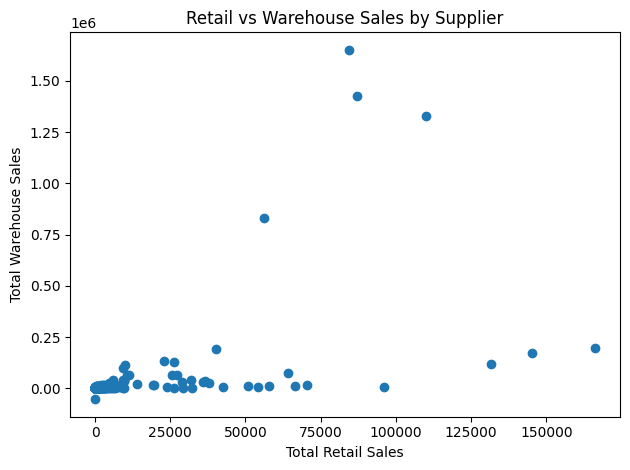

In [37]:
# scatter

scatter_data = (
    df_train.groupby("SUPPLIER")[["RETAIL SALES", "WAREHOUSE SALES"]]
    .sum()
    .reset_index()
)

plt.figure()
plt.scatter(
    scatter_data["RETAIL SALES"],
    scatter_data["WAREHOUSE SALES"]
)
plt.xlabel("Total Retail Sales")
plt.ylabel("Total Warehouse Sales")
plt.title("Retail vs Warehouse Sales by Supplier")
plt.tight_layout()
plt.show()

